In [67]:
# DECONVOLUTION
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm

In [68]:
import sys, subprocess
print("Python del kernel:", sys.executable)

# Se pip non c'è, lo installa
subprocess.call([sys.executable, "-m", "ensurepip", "--upgrade"])

# Aggiorna pip e installa scikit-image nel kernel corrente
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "pip", "setuptools", "wheel"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "scikit-image"])

# Verifica
import skimage
from skimage.restoration import richardson_lucy
print("scikit-image:", skimage.__version__)
print("Import OK:", richardson_lucy.__name__)


Python del kernel: c:\Users\bulga\AppData\Local\Programs\Python\Python311\python.exe
scikit-image: 0.26.0
Import OK: richardson_lucy


In [69]:

lc = 30 #nm
lp = 0.4 #nm
xdag = 10 #nm
dG= 15 # pN* nm
F0 = 8
# double langevin eq cant work since x, y are coupled

def langevin(x, F):
    return 4 * dG * (1/4 * ((x- xdag)/ xdag)**4 - 0.5 *((x - xdag)/ xdag)**2 ) - F *x

x = np.linspace(-10, 30, 100)
U = langevin(x,0 )

# plt.plot(x, U)
# plt.title("Symmetric Potential landscap")
# plt.xlabel("x [nm]")
# plt.ylabel("U [pN * nm]")

# plt.grid("True")
# plt.show()

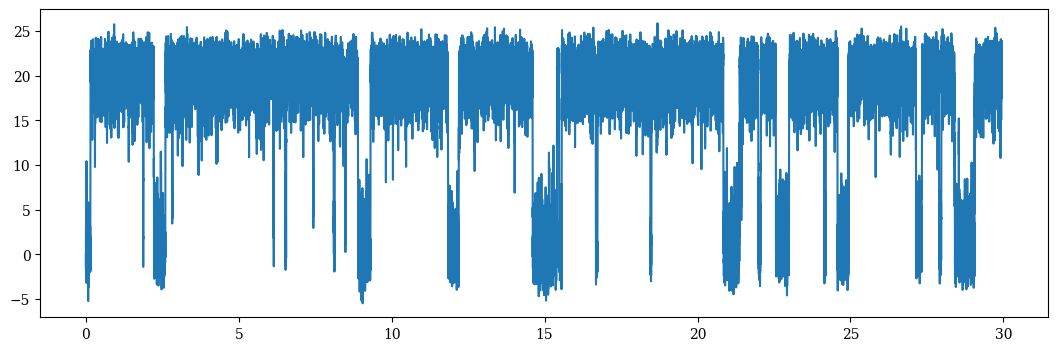

In [70]:
from scipy.signal import fftconvolve

x = np.load("langevinSimulation_F0.5.npz")["data"][:, 1]
t = np.load("langevinSimulation_F0.5.npz")["data"][:, 0]
# x_0 =  np.load("langevinSimulation_F0.npz")["data"][:, 1]

# t,x_traj = np.loadtxt("DATA_WT.txt", unpack=True, skiprows=1)
plt.figure(figsize=(13,4))
plt.plot(t[:59900],x[:59900])


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


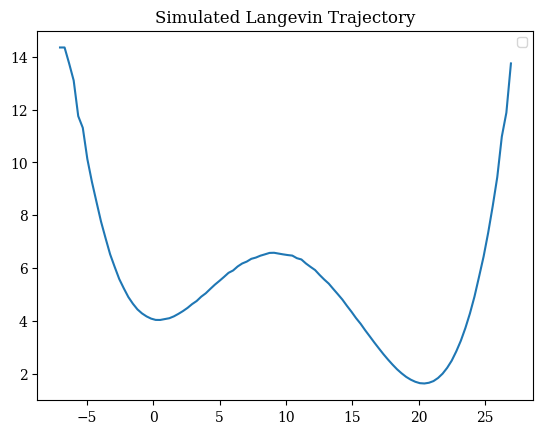

In [71]:
# 2. Istogramma normalizzato
# x_min, x_max = -10, 30
# x_bins = 1000
# x_grid = np.linspace(x_min, x_max, x_bins)
counts, edges = np.histogram(x, bins = 100, density=True) 
x_centers = 0.5 * (edges[:-1] + edges[1:]) # density -> normalizzo hist
# x_centers = 0.5 * (x_grid[1:] + x_grid[:-1])  # serve per centrare hist rispetto a x 
# plt.plot(x_traj[::], langevin(x_traj, 9)[::], "o", markersize=1, label="F= 8.5 pN")
# plt.plot(x_0[::1000], kc(x_0, 0)[::1000], "o", markersize=1, label="F = 8 pN")

U = - np.log(counts + 1e-7)
plt.plot(x_centers, U)
plt.legend()
plt.title("Simulated Langevin Trajectory")
plt.show()

Dimensioni: bc_dec=100, U_dec=100


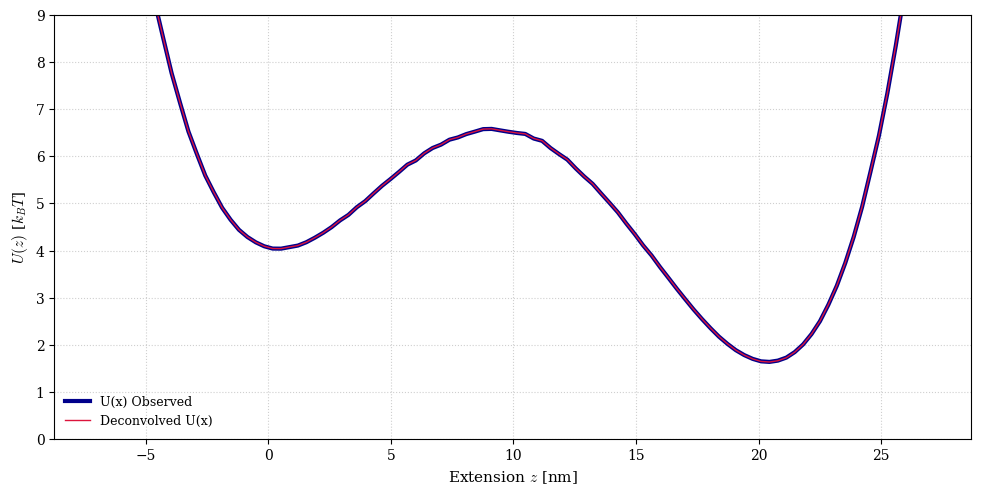

In [79]:
from scipy.signal import find_peaks
from numpy.fft import fftshift
'''
def deconvolvi_Ux(counts, bin_centers, sigma=1.5, n_iter=23, kT=4.11):
      
        L = int(6 * sigma + 1)
        if L % 2 == 0:
            L += 1
        x = np.linspace(-3*sigma, 3*sigma, L)
        kernel = np.exp(-x**2 / (2*sigma**2))
        kernel /= kernel.sum()
        kernel = fftshift(kernel)

        # Usa i dati salvati nell'oggetto
        # try con RL
        from skimage.restoration import richardson_lucy
        restored= richardson_lucy(counts, kernel, num_iter=n_iter, clip=False)
        dx = bin_centers[1] - bin_centers[0]
        restored = np.maximum(restored, 0)
        restored /= (restored.sum() * dx)

        U_dec = - np.log(restored + 1e-7)
        i0 = int(np.nanargmin(-kT*np.log(counts + 1e-7)))  # minimo di U_x
        i1 = int(np.nanargmin(U_dec))
        shift = bin_centers[i0] - bin_centers[i1]
        bin_centers_shifted = bin_centers + shift 

        #U_dec -= np.min(U_dec)  # offset
        return bin_centers_shifted, U_dec, restored

'''

import numpy as np
from scipy.signal import fftconvolve

def deconvolvi_Ux(counts, bin_centers, sigma=1.5, n_iter=700, alpha=0.04, kT=4.11):
    """
    Esegue la deconvolution utilizzando l'algoritmo di Jansson-Van Cittert.
    Output: bin_centers_shifted, U_dec, restored
    """
    # 1. Definizione del kernel Gaussiano (PSF)
    L = int(6 * sigma + 1)
    if L % 2 == 0: L += 1
    x = np.linspace(-3*sigma, 3*sigma, L)
    kernel = np.exp(-x**2 / (2*sigma**2))
    kernel /= kernel.sum()

    # 2. Algoritmo di Deconvolution di Jansson-Van Cittert
    # L'estimate iniziale è il segnale osservato (counts)
    observed = np.copy(counts)
    estimate = np.copy(observed)
    
    for _ in range(n_iter):
        # Riconvoluzione dell'attuale stima
        reconvolved = fftconvolve(estimate, kernel, mode='same')
        
        # Calcolo della correzione (Errore tra osservato e riconvolto)
        correction = observed - reconvolved
        
        # Aggiornamento della stima: update = alpha * errore * stima
        # Questo termine 'estimate' agisce come un vincolo di positività implicito
        estimate += alpha * correction * estimate
        
        # Forza esplicitamente la positività per evitare instabilità numeriche
        estimate[estimate < 0] = 0

    # 3. Normalizzazione della distribuzione restaurata
    restored = estimate
    dx = bin_centers[1] - bin_centers[0]
    restored = np.maximum(restored, 1e-10) # Evita log(0)
    restored /= (restored.sum() * dx)

    # 4. Calcolo dell'energia libera U(z)
    U_dec = -np.log(restored)
    
    # 5. Allineamento (shift) basato sui minimi di energia
    # Cerchiamo il minimo del potenziale osservato e di quello deconvolto
    i0 = int(np.nanargmin(-np.log(counts + 1e-7))) 
    i1 = int(np.nanargmin(U_dec))
    
    shift = bin_centers[i0] - bin_centers[i1]
    bin_centers_shifted = bin_centers + shift 

    return bin_centers_shifted, U_dec, restored

# 1. Esegui la deconvolution
bc_dec, U_dec, pdf_dec = deconvolvi_Ux(counts, x_centers, sigma=1.5, n_iter=9, kT=4.11)

# 2. Verifica le dimensioni (DEBUG)
print(f"Dimensioni: bc_dec={len(bc_dec)}, U_dec={len(U_dec)}")

# 3. Se le dimensioni non coincidono, correggi l'array più lungo
# Spesso succede se x_centers non è stato filtrato come counts
if len(bc_dec) != len(U_dec):
    # Adattiamo bc_dec alla lunghezza di U_dec (prendendo ad esempio i primi N elementi)
    bc_dec = bc_dec[:len(U_dec)]

# 4. Ora puoi unire e salvare senza errori
data = np.column_stack((bc_dec, U_dec))
np.savetxt('WT_deconvolution_results.txt', data, 
           header='bc_dec\tU_dec', 
           delimiter='\t', 
           fmt='%.6e')

# 5. Plot (assicurati che x_centers e U abbiano la stessa lunghezza qui)
plt.figure(figsize=(10,5))
plt.plot(x_centers[:len(U)], U, label="U(x) Observed", c="darkblue", lw=3)
plt.plot(bc_dec, U_dec, label="Deconvolved U(x)", c="crimson", lw=1)
plt.xlabel("Extension $z$ [nm]")
plt.ylabel("$U(z)$ [$k_B T$]")
plt.legend(frameon=False)
plt.grid(True, ls=':', alpha=0.6)
plt.tight_layout()
plt.ylim(0, 9)
plt.show()



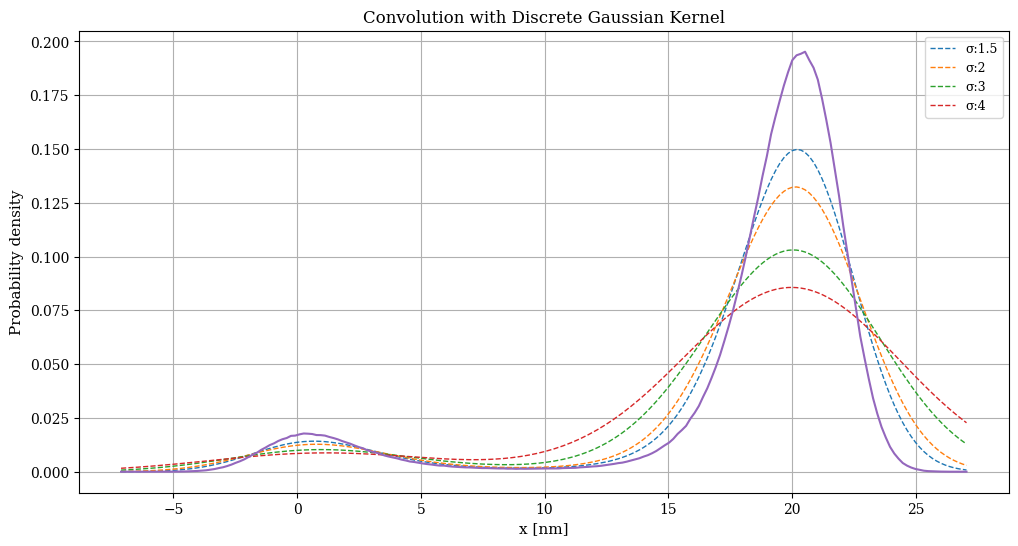

In [89]:
import numpy as np
from scipy.signal import convolve

# 1. Risoluzione dei dati
dx = x_centers[1] - x_centers[0]

sym_gaussian = []
kernel = []

# 2. Intervallo fisico del kernel: ±3σ (copre 99.7% della Gaussiana)
plt.figure(figsize=(12, 6))

for sigma in (1.5,2,3,4):
# sigma = 1.5  # in nm
    kernel_width_physical = 6 * sigma  # da -3σ a +3σ
    kernel_points = int(kernel_width_physical / dx)
    if kernel_points % 2 == 0:
        kernel_points += 1  # per simmetria

    x_kernel = np.linspace(-3 * sigma, 3 * sigma, kernel_points)
    gaussian_kernel = np.exp(-x_kernel**2 / (2 * sigma**2))
    gaussian_kernel /= np.sum(gaussian_kernel) # normalizzo 

    signal_disturbed = convolve(hist_sim, gaussian_kernel, mode='same')
    signal_disturbed /= np.trapz(signal_disturbed, x_centers) # ri normalizzo
    
    kernel.append(gaussian_kernel)
    sym_gaussian.append(signal_disturbed.copy())

    plt.plot(x_centers, signal_disturbed, label="σ"f':{sigma}', lw=1, linestyle='--')
    plt.xlabel("x [nm]")
    plt.ylabel("Probability density")
    plt.title("Convolution with Discrete Gaussian Kernel")
    plt.legend()
    plt.grid(True)

plt.plot(x_centers, hist_sim, label="Original Histogram", lw=1.5)
plt.show()

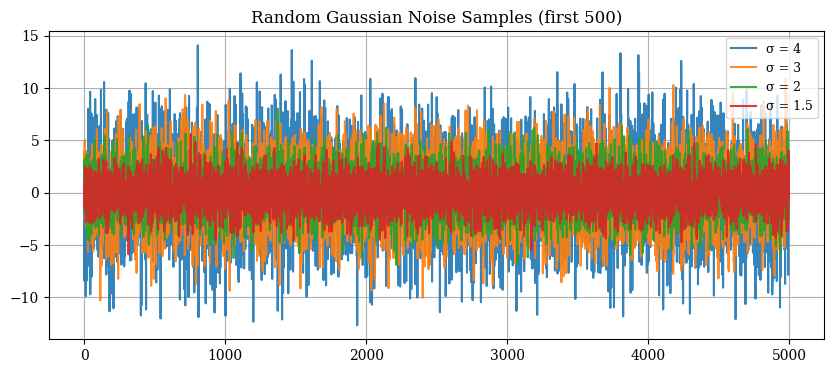

In [81]:
# add NOISE with SOMMATION 
# noise generation 

sigma = [4,3,2,1.5]
l = len(x)
noises = {i: np.random.normal(loc=0.0, scale=i, size=l) for i in sigma}
plt.figure(figsize=(10, 4))
for i in sigma:
    plt.plot(noises[i][:5000], label=f"σ = {i}", alpha=0.9)
plt.legend()
plt.title("Random Gaussian Noise Samples (first 500)")
plt.grid(True)
plt.show()

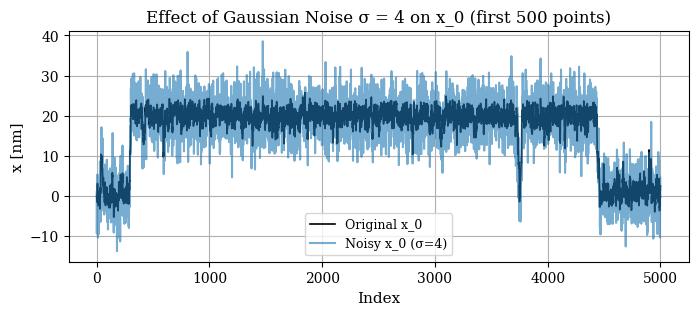

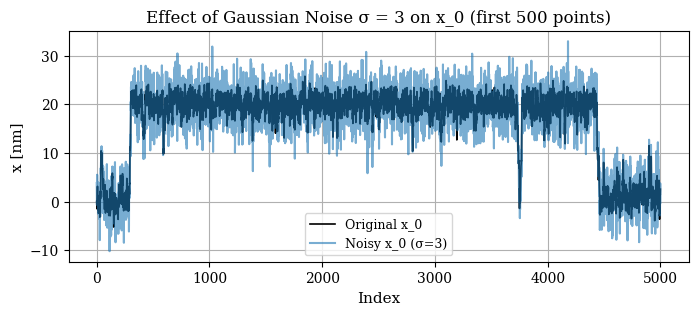

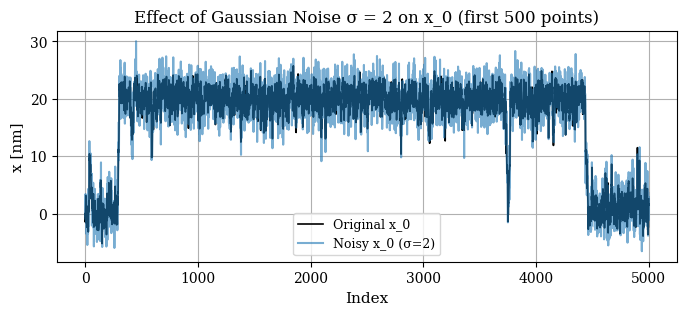

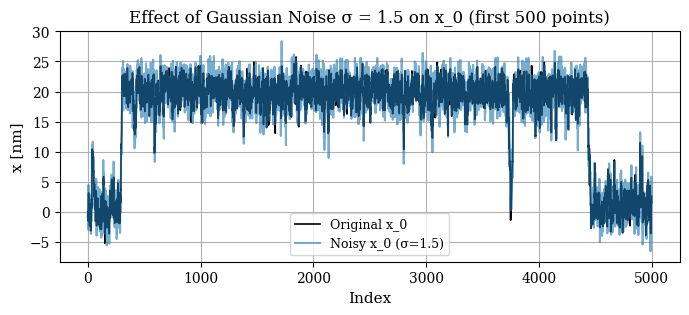

In [82]:
# Crea nuove traiettorie rumorose sommando il noise
xtraj_noisy = {s: x + noises[s] for s in sigma}

for s in sigma:
    plt.figure(figsize=(8, 3))
    plt.plot(x[:5000], label='Original x_0', color='black', linewidth=1.2)
    plt.plot(xtraj_noisy[s][:5000], label=f"Noisy x_0 (σ={s})", alpha=0.6)

    plt.title(f"Effect of Gaussian Noise σ = {s} on x_0 (first 500 points)")
    plt.xlabel("Index")
    plt.ylabel("x [nm]")
    plt.grid(True)
    plt.legend()
    plt.show()


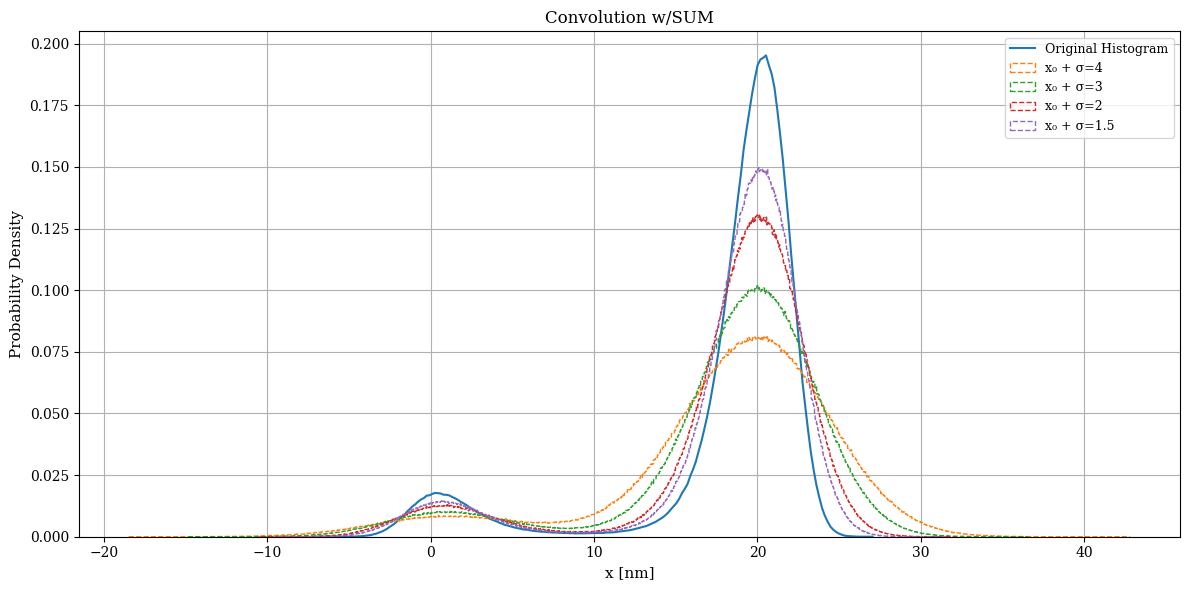

In [83]:
plt.figure(figsize=(12, 6))
x_grid = np.linspace(np.min(x), np.max(x), 201)
hist_sim, _ = np.histogram(x, bins=200, density=True)  # density -> normalizzo hist
x_centers = 0.5 * (x_grid[1:] + x_grid[:-1])  # serve per centrare hist rispetto a x 
plt.plot(x_centers, hist_sim, label="Original Histogram", lw=1.5)

for s in sigma:
    noise = noises[s]
    x_noisy = x + noise
    plt.hist(x_noisy, bins=1000, density=True, linestyle = '--', histtype='step', label=f"x₀ + σ={s}")

plt.xlabel("x [nm]")
plt.ylabel("Probability Density")
plt.title("Convolution w/SUM")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [84]:
from scipy.signal import fftconvolve

def jansson_deconvolution(observed, kernel, iterations=700, alpha=0.1):

    kernel = kernel / np.sum(kernel)
    estimate = np.copy(observed)
    
    for _ in range(iterations):
        reconvolved = fftconvolve(estimate, kernel, mode='same')
        # usa una regolarizzazione minima per evitare annullamenti
        correction = observed - reconvolved
        update = alpha * correction * estimate
        estimate += update
        estimate[estimate < 0] = 0  # forza positività

    return estimate


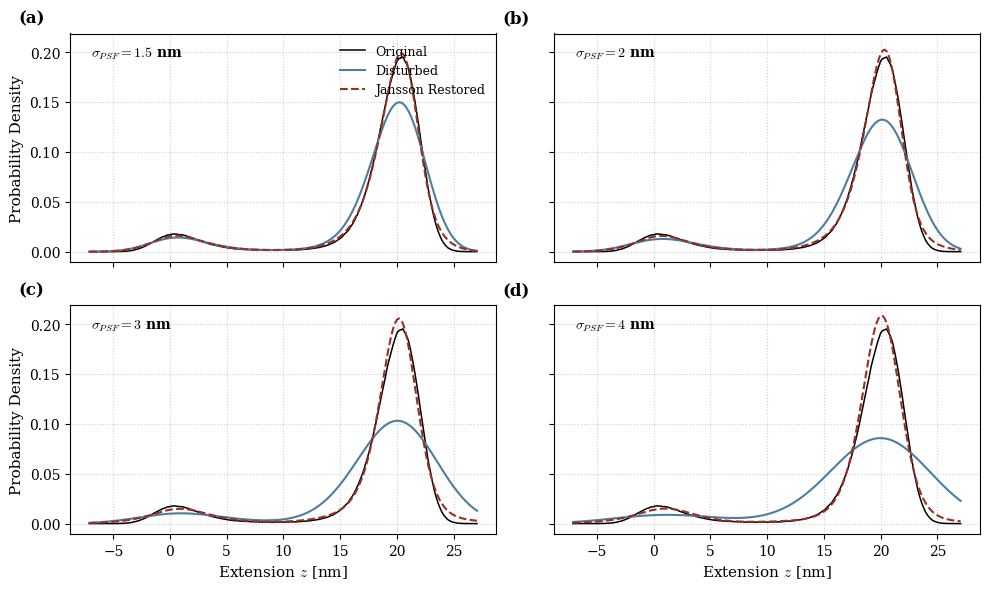

In [92]:


# 2. Parametri (assicurati che sigmas sia una lista)
sigmas_list = [1.5, 2, 3, 4]
alpha_params = {1.5: 0.04, 2: 0.06, 3: 0.15, 4: 0.3}
iter_params = {1.5: 2500, 2: 3000, 3: 2500, 4: 3000}

# 3. Configurazione Stile Professionale (Serif/LaTeX)
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'mathtext.fontset': 'cm'
})

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
axes = axes.flatten()

# Colori professionali
color_disturbed = "#4E7E9D" # Blue
color_restored = "#992f24"  # Red/Crimson
color_original = 'black'
# ... (mantieni le definizioni precedenti)

labels = ['(a)', '(b)', '(c)', '(d)']

for idx, (sigma, disturbed_signal, k_signal) in enumerate(zip(sigmas_list, sym_gaussian, kernel)):
    ax = axes[idx]

    # Esecuzione Deconvoluzione
    alpha = alpha_params[sigma]
    iters = iter_params[sigma]
    restored = jansson_deconvolution(disturbed_signal, k_signal, iterations=iters, alpha=alpha)

    # Plotting
    ax.plot(x_centers, hist_sim, color=color_original, label="Original", lw=1.1, alpha=1)
    ax.plot(x_centers, disturbed_signal, color=color_disturbed, label=f"Disturbed", lw=1.5)
    ax.plot(x_centers, restored, color=color_restored, label="Jansson Restored", lw=1.5, linestyle='--')

    # Indice del pannello (a, b, c, d)
    ax.text(-0.12, 1.05, labels[idx], transform=ax.transAxes, fontsize=12, fontweight='bold')

    # Annotazione sigma interna
    ax.text(0.05, 0.9, f"$\sigma_{{PSF}} = {sigma}$ nm", transform=ax.transAxes, fontweight='bold', fontsize=10)

    ax.grid(True, linestyle=':', alpha=0.6)

    if idx >= 2: ax.set_xlabel("Extension $z$ [nm]")
    if idx % 2 == 0: ax.set_ylabel("Probability Density")
    if idx == 0: ax.legend(frameon=False, loc='upper right')

plt.tight_layout()
plt.savefig('jansson_comparison_2x2.pdf', bbox_inches='tight')
plt.show()

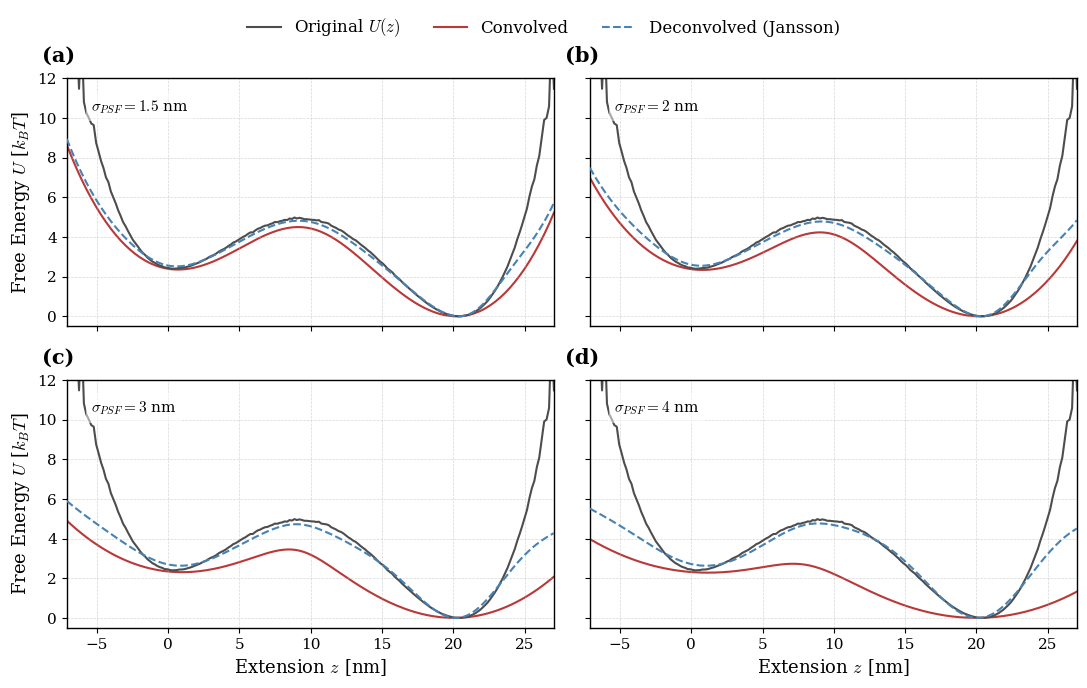

In [116]:
import numpy as np
import matplotlib.pyplot as plt

# --- Configurazione Stile Professionale ---
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'mathtext.fontset': 'cm',
    'axes.linewidth': 1.0
})

fig, axes = plt.subplots(2, 2, figsize=(11,7), sharex=True, sharey=True)
axes = axes.flatten()
labels = ['(a)', '(b)', '(c)', '(d)']

# Palette colori raffinata
color_orig = '#4D4D4D'  # Grigio antracite per l'originale
color_conv = '#B22222'  # Firebrick red per il convolved
color_deco = '#4682B4'  # Steel blue per il deconvolved

for idx, (sigma, dist_signal) in enumerate(zip(sigmas_list, sym_gaussian)):
    ax = axes[idx]
    
    # Ricalcolo per consistenza
    restored = jansson_deconvolution(dist_signal, kernel[idx], 
                                     iterations=iter_params[sigma], 
                                     alpha=alpha_params[sigma])
    
    # Trasformazione Logaritmica (Free Energy)
    U_orig = -np.log(hist_sim + 1e-7)
    U_conv = -np.log(dist_signal + 1e-7)
    U_deco = -np.log(restored + 1e-7)
    
    # Allineamento dei minimi a zero
    U_orig -= np.nanmin(U_orig)
    U_conv -= np.nanmin(U_conv)
    U_deco -= np.nanmin(U_deco)
    
    # Plotting con spessori differenziati
    ax.plot(x_centers, U_orig, color=color_orig, lw=1.5, label="Original $U(z)$", zorder=2)
    ax.plot(x_centers, U_conv, color=color_conv, lw=1.5, label="Convolved", alpha=0.9, zorder=1)
    ax.plot(x_centers, U_deco, color=color_deco, lw=1.5, ls='--', label="Deconvolved (Jansson)", zorder=3)
    
    # Label del pannello (a, b, c, d) fuori dal grafico
    ax.text(-0.05, 1.05, labels[idx], transform=ax.transAxes, fontsize=15, fontweight='bold', va='bottom')
    
    # Annotazione Sigma elegante (box semitrasparente opzionale)
    ax.text(0.05, 0.92, f"$\\sigma_{{PSF}} = {sigma}$ nm", transform=ax.transAxes, 
            verticalalignment='top', fontsize=11, fontweight='medium',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))
    
    # Griglia discreta
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
    ax.set_ylim(-0.5,12)
    ax.set_xlim(x_centers.min() , x_centers.max())

# Gestione etichette assi (solo esterni)
for i in [2, 3]: axes[i].set_xlabel("Extension $z$ [nm]")
for i in [0, 2]: axes[i].set_ylabel("Free Energy $U$ [$k_B T$]")

# Legenda unica posizionata sopra i grafici per non coprire le barriere
handles, plot_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, plot_labels, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=3, frameon=False, fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Lascia spazio per la legenda superiore
plt.savefig('jansson_Ux_professional.pdf', bbox_inches='tight', dpi=300)
plt.show()

C:\Users\bulga\AppData\Local\Temp\ipykernel_17108\2566542677.py:3: RuntimeWarning: divide by zero encountered in log
  G = - np.log(hist_sim)


ValueError: x and y must have same first dimension, but have shapes (200,) and (123,)

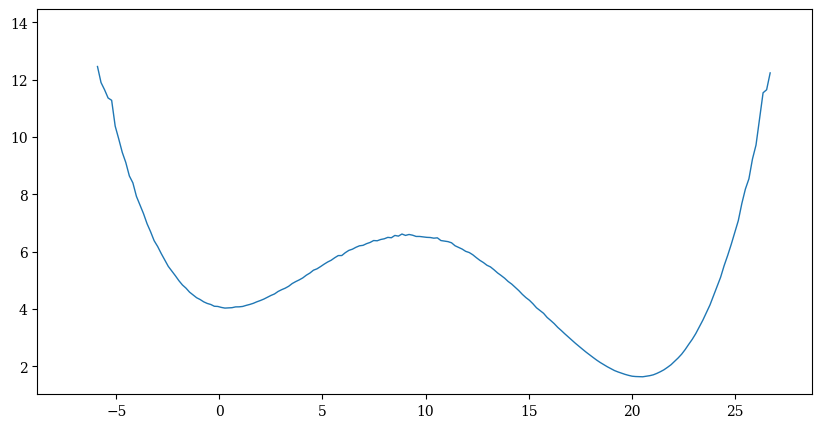

In [99]:
# BOLTZMAN DECONVOLUTION
kT = 4.11  # pN * nm
G = - np.log(hist_sim)  
for i, q, sigma in zip(deconvolution, sym_gaussian, [1.5,2,3,4]):# free energy from histogram
    G1 = - np.log(i)  # free energy from restored histogram
    G2 = - np.log(q)  # free energy from disturbed histogram

    plt.figure(figsize=(10, 5))
    plt.plot(x_centers, G, label="Real", lw=1)
    plt.plot(x_centers, G1, label="deconvolution", lw=1.4)
    plt.plot(x_centers, G2, label="convolution", lw=1, linestyle='--', c="g")
    plt.title(f"Free Energy from Histograms w/  σ={sigma}nm")
    plt.grid(True)
    plt.ylabel("Free Energy [kbT]")
    plt.legend()
 

In [56]:
# WLC + MORSE POTENTIAL LANDSCAPE
from scipy.signal import savgol_filter

kT = 4.11 #pN 
z = np.linspace(-4, 39, 350) 
lc, lp = 30, 0.4 #nm
F = 8 #pN

def F_wlc(dz, lc= 45, lp= 0.5):
    Fwlc = (kT / lp) * (1 / 4 * (1 - dz / lc)**(-2) + dz / lc - 1/4)
    return Fwlc
def U_wlc(z, F, lc, lp):
    U = (kT / lp) * (-0.25 * (lc**2) / (z - lc) + z**2 / (2 * lc) - 0.25 * z) - F * z
    return U
def U_fold_fit(z, a, G0, U0, s, x_dag):
    return U0 * (1 - np.exp(-a * z))**2 + G0 * np.exp(-((z - x_dag)**2) / s)
def U_total_fit(z, a, G0, U0, s, x_dag, lc, lp):
    offset = U_wlc(z, F, lc, lp)[0]  # F deve essere definito globalmente o passato
    return U_wlc(z, F, lc, lp) - offset + U_fold_fit(z, a, G0, U0, s, x_dag)

df = pd.read_csv("Free_energy.txt", header=None, names=["U"])

x_values = -26.6 + 0.22 * np.arange(350)
df["x"] = x_values
x = df["x"]
x = np.array(x)

mask = (x > 0)& (x < 27)
x_fit = x[mask]
popt= [2.31732031e-01, 1.07022786e+02, 8.74200495e+01, 4.28319315e+02, 3.82153462e+01, 5.00000000e+01, 1.00000000e+00]
y_finalfit = U_total_fit(x_fit, *popt)


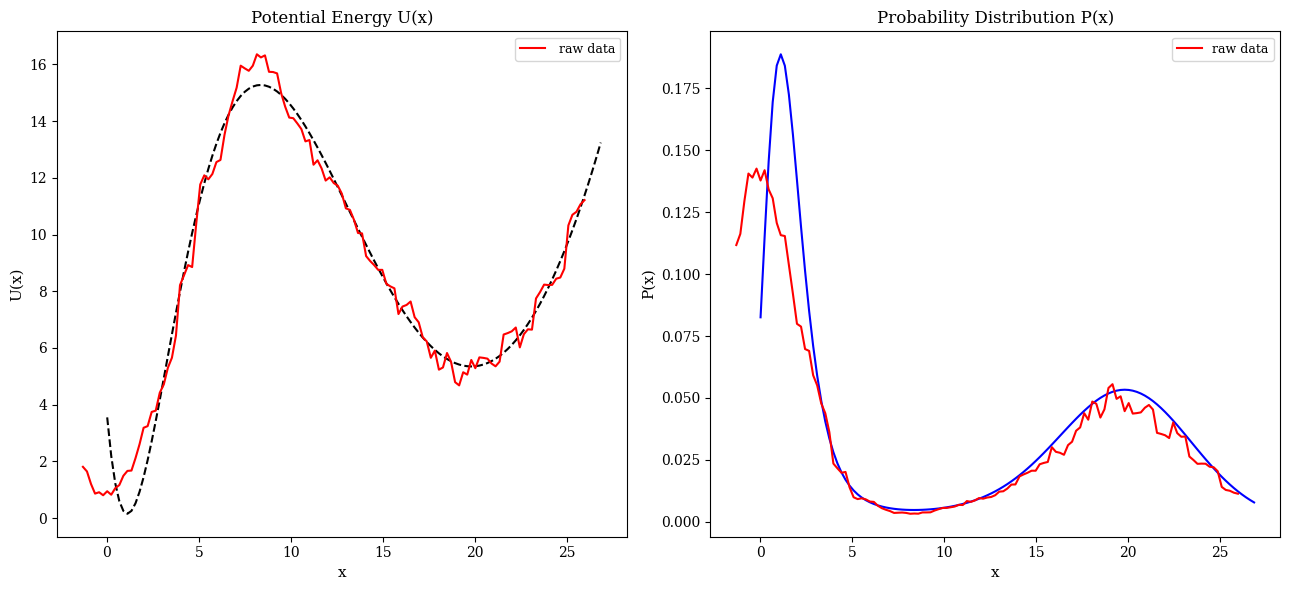

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# PDF from fit
pdf = np.exp(- y_finalfit / kT)
pdf /= np.trapz(pdf, x_fit)  # normalizzazione

# PDF from raw data
pdf1 = np.exp(- df["U"][115:240]/kT)
pdf1 /= np.trapz(pdf1, df["x"][115:240])  # normalizzazione

plt.figure(figsize=(13, 6))
plt.subplot(1, 2, 1)
plt.plot(x_fit, y_finalfit, 'k--')
plt.plot(df["x"][115:240], df["U"][115:240], 'r', lw=1.5, label=" raw data")
plt.title("Potential Energy U(x)")
plt.xlabel("x")
plt.ylabel("U(x)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x_fit, pdf, 'b')
plt.plot(df["x"][115:240], pdf1, 'r', lw=1.5, label = "raw data")
plt.title("Probability Distribution P(x)")
plt.xlabel("x")
plt.ylabel("P(x)")

plt.legend()
plt.tight_layout()
plt.show()


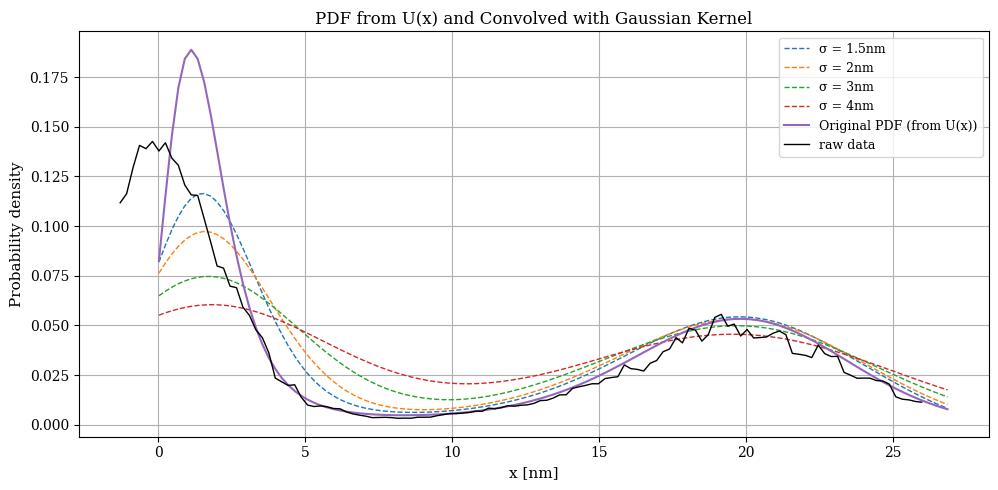

In [58]:
convolution = []
kernel= []
plt.figure(figsize=(10, 5))

# Kernel gaussiano
for sigma in (1.5, 2, 3, 4):

    dx = x_fit[1] - x_fit[0]
    n_points = int(6 * sigma / dx)
    if n_points % 2 == 0:
        n_points += 1

    x_kernel = np.linspace(-3 * sigma, 3 * sigma, n_points)
    gaussian_kernel = np.exp(-x_kernel**2 / (2 * sigma**2))
    gaussian_kernel /= np.sum(gaussian_kernel)

    kernel.append(gaussian_kernel)
    # Convoluzione con kernel gaussiano 

    pdf_disturbed = convolve(pdf, gaussian_kernel, mode='same')
    pdf_disturbed /= np.trapz(pdf_disturbed, x_fit)

    convolution.append(pdf_disturbed.copy())

# ### kernel WLC : MARKO SIGGAARD
# xl = np.linspace(0.01, lc - 0.1*lc, 1000) # linker extension

# def U_linker (x, F, lc = 15, lp = 0.5):
#     term1 = 1 / (4 * (1 - x / lc)**2) - 0.25 + x / lc
#     return F * x - kT * term1 / lp  # Helmholtz Free Energy

# U_linker  = U_linker(xl, F, lc, lp)
# U_linker = np.clip(U_linker, -500, 500) 
# P_x = np.exp(-U_linker / kT)
# P_x = np.nan_to_num(P_x)  # Sostituisce NaN/Infs con 0
# P_x /= np.trapz(P_x, xl)  # Normalizzazione

# ### convolution kernel WLC
# from scipy.signal import fftconvolve
# from scipy.fft import fft, ifft, fftfreq

# P_prot_fft = fft(pdf, n=len(pdf) + len(P_x) - 1)
# P_linker_fft = fft(P_x, n=len(pdf) + len(P_x) - 1)
# P_tot_fft = P_prot_fft * P_linker_fft
# P_tot = np.real(ifft(P_tot_fft))
# P_tot = P_tot[:len(pdf)]
# P_tot /= np.trapz(P_tot, x_fit)  # Normalizzazione

#---------------------------------------------------------------------------------------
for q, i in zip(convolution, [1.5, 2, 3, 4]):
    plt.plot(x_fit, q, label=f"σ = {i}nm", lw=1, linestyle='--')
    # plt.plot(x_fit, P_tot, label="WLC kernel (P tot)", lw=1.5, linestyle='--')
    plt.xlabel("x [nm]")
    plt.ylabel("Probability density")
    plt.title("PDF from U(x) and Convolved with Gaussian Kernel")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

plt.plot(x_fit, pdf, label="Original PDF (from U(x))", lw=1.5)
plt.plot(df["x"][115:240], pdf1, label="raw data", lw=1, c="black")
plt.legend()
plt.show()

#vediamo se model + convoluzione è simile ai dati lab 

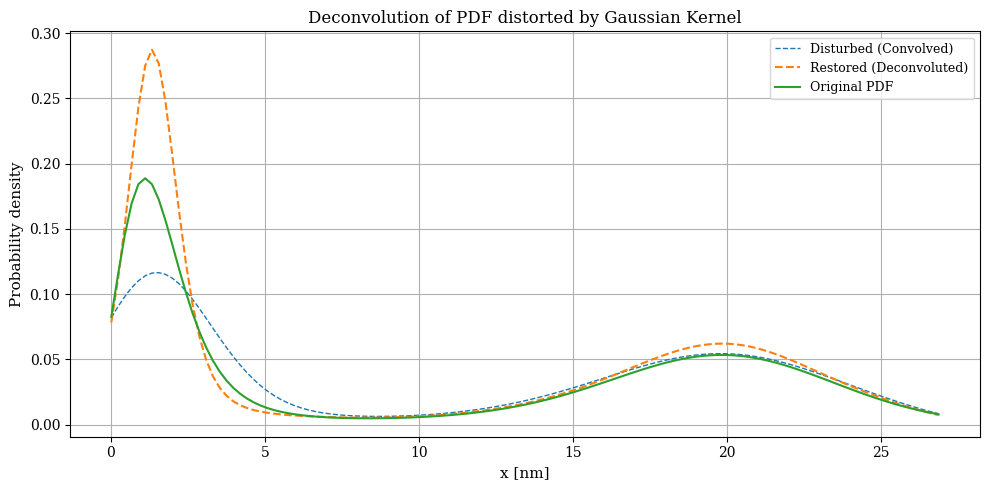

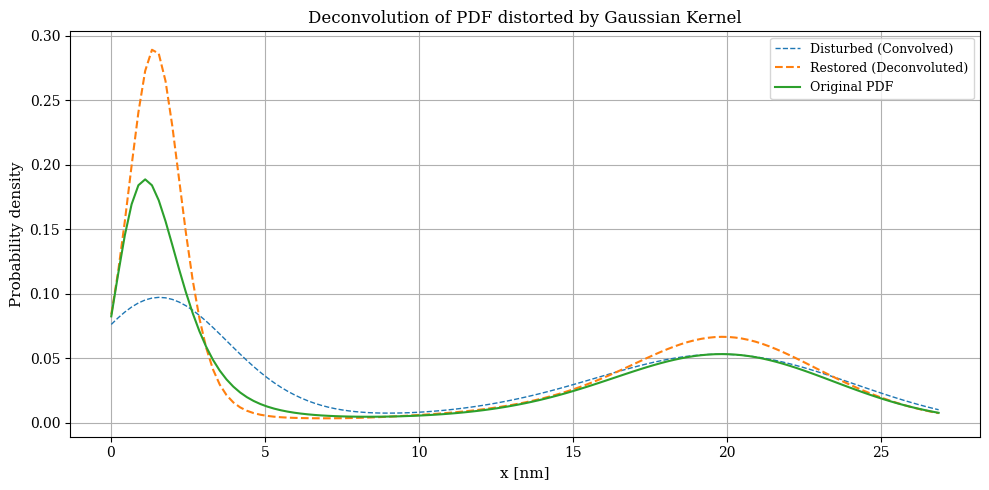

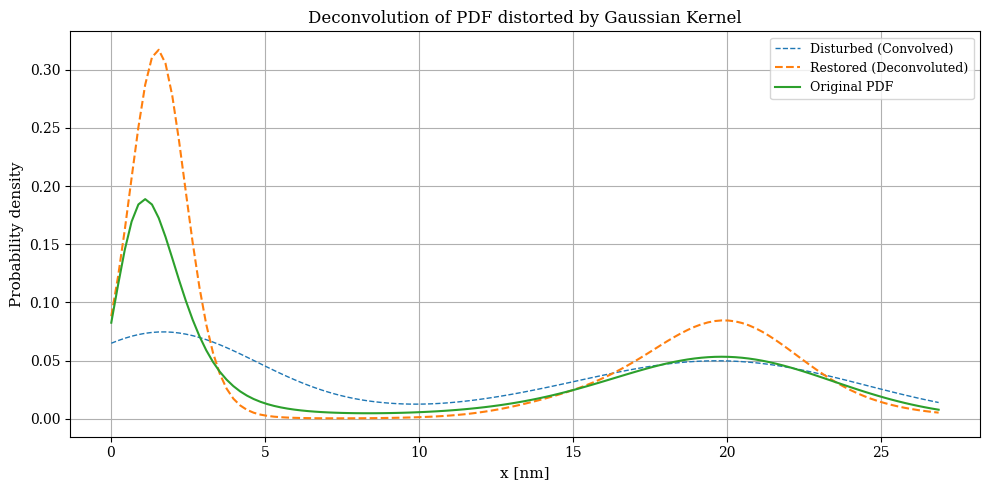

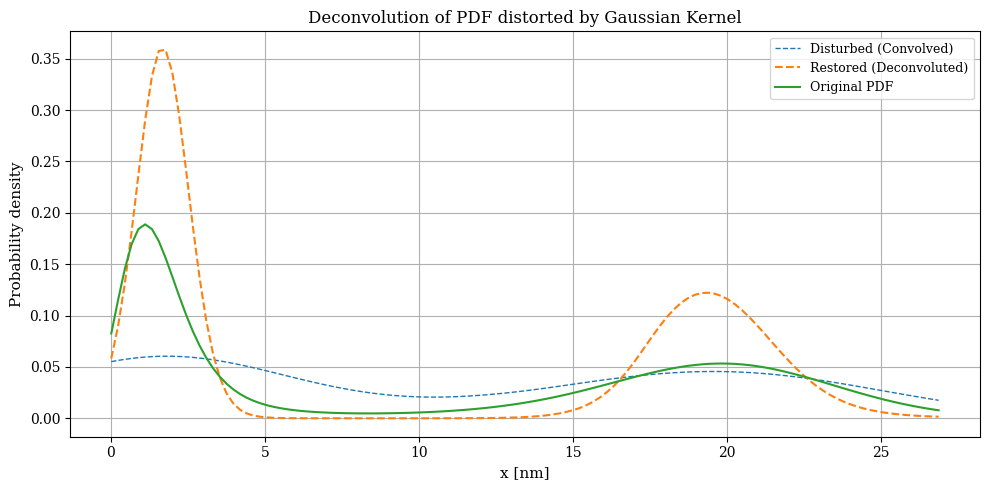

In [98]:
alpha_values = {1.5: 0.04,   2: 0.06,    3: 0.15,    4: 0.3}
iterations_values = {1.5: 2500,   2: 3000,    3: 2500,    4: 3500}
deconvolution=[]

for q, i, m in zip(convolution, [1.5, 2, 3, 4], kernel):
    alpha = alpha_values[i]
    iterations = iterations_values[i]

    pdf_restored = jansson_deconvolution(q, m, iterations=iterations, alpha=alpha)
    deconvolution.append(pdf_restored.copy())

    plt.figure(figsize=(10, 5))
    plt.plot(x_fit, q, label="Disturbed (Convolved)", lw=1, linestyle='--')
    plt.plot(x_fit, pdf_restored, label="Restored (Deconvoluted)", lw=1.5, linestyle='--')
    plt.plot(x_fit, pdf, label="Original PDF", lw=1.5)

    plt.xlabel("x [nm]")
    plt.ylabel("Probability density")
    plt.title("Deconvolution of PDF distorted by Gaussian Kernel")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    # plt.plot(df["x"][115:240], pdf1, label="raw data", lw=1.5, linestyle='--', c="r")
    plt.show()


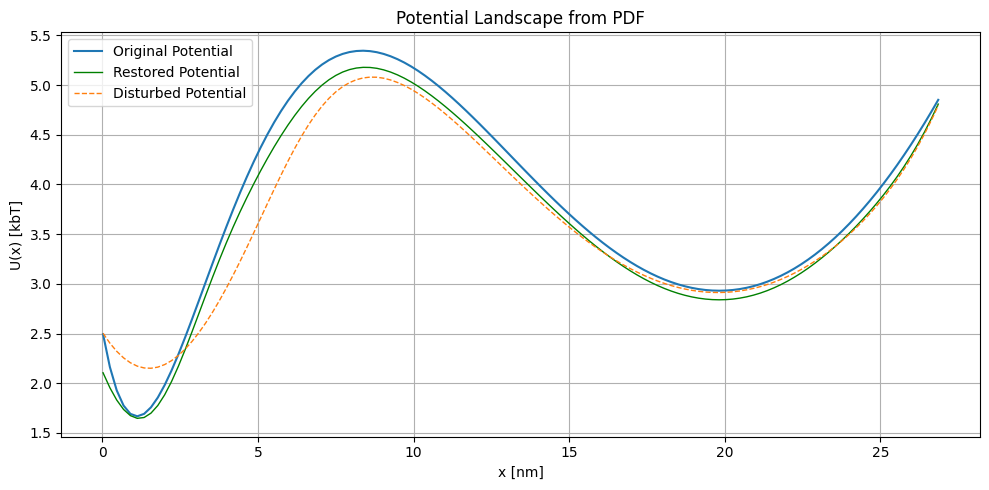

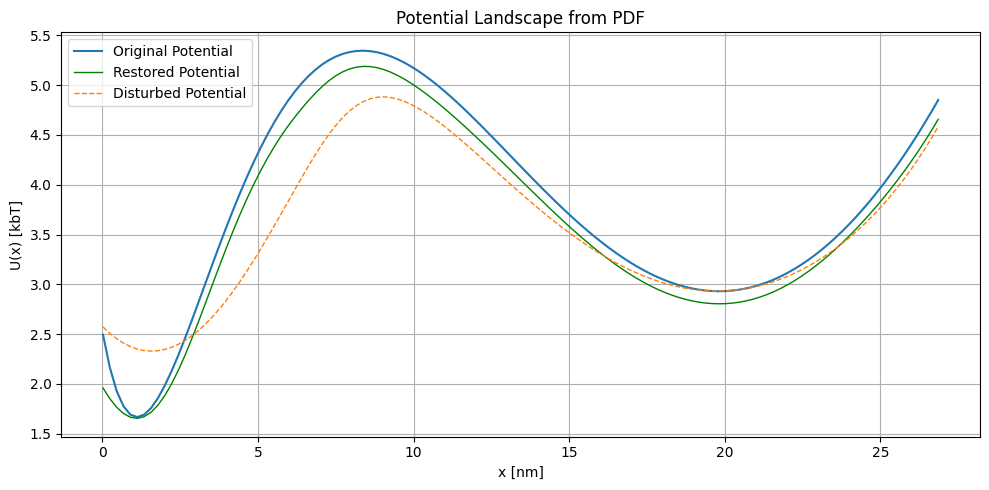

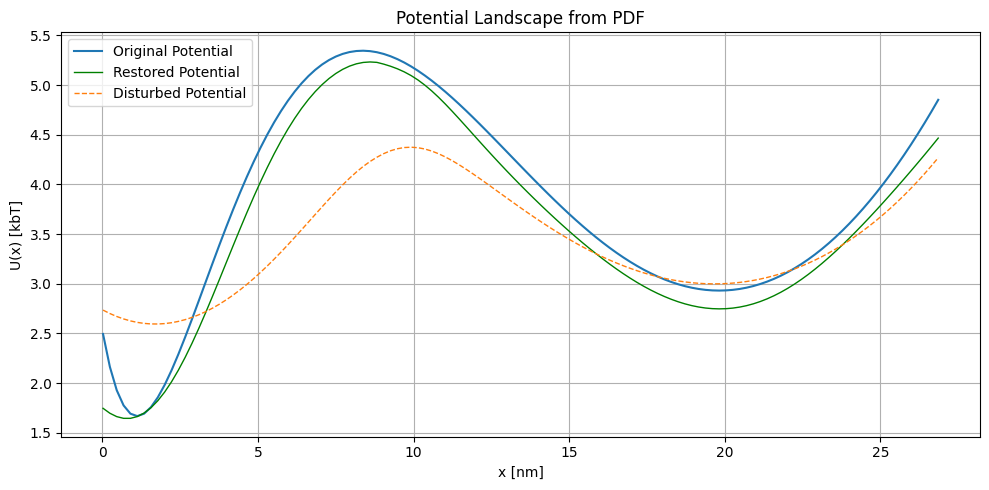

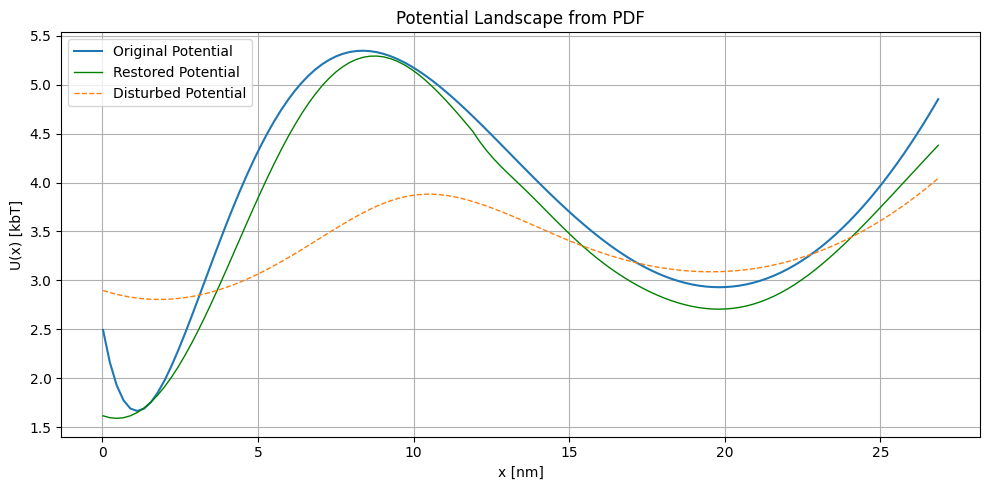

In [ ]:
# recovering potential landscape from pdf

U = - np.log(pdf)
for q, m, i in zip(deconvolution, convolution, [1.5, 2, 3, 4]):
    U1= - np.log(q)
    U2= - np.log(m)
    
    plt.figure(figsize=(10, 5))
    plt.plot(x_fit, U, label="Original Potential", lw=1.5)
    plt.plot(x_fit, U1, label="Restored Potential", lw=1, c="g")
    plt.plot(x_fit, U2, label="Disturbed Potential", lw=1,  linestyle='--')
    plt.title("Potential Landscape from PDF")
    plt.xlabel("x [nm]")
    plt.ylabel("U(x) [kbT]")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
plt.show()